In [1]:
get_ipython().system('pip install -q gdown torch torchvision facenet-pytorch opencv-python-headless kornia')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 83.3 MB/s eta 0:00:00


In [4]:
from google.colab import drive
import zipfile
drive.mount('/content/drive')

with zipfile.ZipFile('/content/drive/MyDrive/mask_aligned_faces.zip', 'r') as z:
    z.extractall('/content/mask_aligned_faces')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os, shutil, zipfile, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import kornia.augmentation as K
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import gdown
import kagglehub
from facenet_pytorch import MTCNN

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


In [6]:
ALIGNED_DIR = '/content/mask_aligned_faces'
DATASET_DIR = '/content/mask_split_dataset'
CLASS_NAMES = ['no_mask', 'correct', 'incorrect']

split_ratios = {'train': 0.80, 'val': 0.10, 'test': 0.10}

for split in split_ratios.keys():
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(DATASET_DIR, split, cls), exist_ok=True)

for cls in CLASS_NAMES:
    images = list(Path(os.path.join(ALIGNED_DIR, cls)).glob('*.jpg'))
    np.random.shuffle(images)
    total_imgs = len(images)

    tr_count = int(total_imgs * split_ratios['train'])
    vl_count = int(total_imgs * split_ratios['val'])

    splits = {
        'train': images[:tr_count],
        'val':   images[tr_count:tr_count + vl_count],
        'test':  images[tr_count + vl_count:],
    }

    for split_name, split_imgs in splits.items():
        for img_path in split_imgs:
            shutil.copy2(img_path, os.path.join(DATASET_DIR, split_name, cls, img_path.name))

    print(f"{cls}: train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])}")

no_mask: train=8000, val=1000, test=1000
correct: train=8000, val=1000, test=1000
incorrect: train=8000, val=1000, test=1000


In [7]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 128

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def build_cache(dataset_dir, class_names, split='train', img_size=(224, 224)):
    cache_img = f'/content/{split}_imgs.npy'
    cache_lbl = f'/content/{split}_lbls.npy'

    if os.path.exists(cache_img):
        print(f"Cache found for {split}, loading...")
        return np.load(cache_img, mmap_mode='r'), np.load(cache_lbl)

    print(f"Building cache for {split}...")
    samples = []
    for idx, cls in enumerate(class_names):
        cls_dir = Path(dataset_dir) / split / cls
        for f in cls_dir.glob('*.jpg'):
            samples.append((str(f), idx))

    imgs = np.zeros((len(samples), img_size[0], img_size[1], 3), dtype=np.uint8)
    lbls = np.zeros(len(samples), dtype=np.int64)

    for i, (path, label) in enumerate(samples):
        img = cv2.imread(path)
        imgs[i] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        lbls[i] = label
        if i % 1000 == 0:
            print(f"  {i}/{len(samples)}")

    np.save(cache_img, imgs)
    np.save(cache_lbl, lbls)
    return np.load(cache_img, mmap_mode='r'), lbls


class CachedDataset(Dataset):
    def __init__(self, imgs, lbls, transform=None):
        self.imgs      = imgs
        self.lbls      = lbls
        self.transform = transform

    def __len__(self):
        return len(self.lbls)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.imgs[idx].copy()).permute(2, 0, 1).float().div(255)
        if self.transform:
            img = self.transform(img)
        return img, int(self.lbls[idx])


# ── GPU augmentation pipeline (runs on batches after .to(device)) ─────────────
train_aug = nn.Sequential(
    K.RandomRotation(degrees=20),
    K.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    K.RandomAffine(degrees=0, shear=20, p=0.5),
    K.RandomResizedCrop(size=IMG_SIZE, scale=(0.8, 1.0), ratio=(0.8, 1.2)),
    K.RandomHorizontalFlip(),
    K.ColorJitter(brightness=0.2, contrast=0.2),
    K.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

val_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_imgs, train_lbls = build_cache(DATASET_DIR, CLASS_NAMES, 'train')
val_imgs,   val_lbls   = build_cache(DATASET_DIR, CLASS_NAMES, 'val')
test_imgs,  test_lbls  = build_cache(DATASET_DIR, CLASS_NAMES, 'test')

train_ds = CachedDataset(train_imgs, train_lbls, transform=None)
val_ds   = CachedDataset(val_imgs,   val_lbls,   transform=val_norm)
test_ds  = CachedDataset(test_imgs,  test_lbls,  transform=val_norm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

NUM_CLASSES = len(CLASS_NAMES)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")


Building cache for train...
  0/24000
  1000/24000
  2000/24000
  3000/24000
  4000/24000
  5000/24000
  6000/24000
  7000/24000
  8000/24000
  9000/24000
  10000/24000
  11000/24000
  12000/24000
  13000/24000
  14000/24000
  15000/24000
  16000/24000
  17000/24000
  18000/24000
  19000/24000
  20000/24000
  21000/24000
  22000/24000
  23000/24000
Building cache for val...
  0/3000
  1000/3000
  2000/3000
Building cache for test...
  0/3000
  1000/3000
  2000/3000
Train: 24000  Val: 3000  Test: 3000


In [10]:
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

In [11]:
class MobileNetV3SmallClassifier(nn.Module):
    def __init__(self, num_classes=3, dropout_rate=0.5):
        super().__init__()
        self.backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 1024),
            nn.Hardswish(),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


model     = MobileNetV3SmallClassifier(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

try:
    model = torch.compile(model, mode='reduce-overhead', fullgraph=True)
    print("torch.compile enabled (fullgraph=True)")
except Exception as e:
    print(f"torch.compile unavailable ({e}); running eager mode")

print(model)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 49.4MB/s]


torch.compile enabled (fullgraph=True)
OptimizedModule(
  (_orig_mod): MobileNetV3SmallClassifier(
    (backbone): MobileNetV3(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): Hardswish()
        )
        (1): InvertedResidual(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 16, kernel_size=(1, 1), st

In [12]:
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        with torch.no_grad():
            x = train_aug(x)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            out  = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                out  = model(x)
                loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += x.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=30):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc  = 0.0
    best_state    = None
    no_improve    = 0
    lr_patience   = 5
    stop_patience = 10

    for epoch in range(epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = validate_epoch(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f"Epoch {epoch+1}/{epochs}  "
              f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
              f"vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.4f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), 'best_model_ternary.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve % lr_patience == 0:
                for pg in optimizer.param_groups:
                    pg['lr'] *= 0.2
                print(f"  LR reduced -> {optimizer.param_groups[0]['lr']:.2e}")
            if no_improve >= stop_patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [13]:
model, history_p1 = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=30
)

W0620 02:22:00.401000 5164 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1/30  tr_loss=0.0509  tr_acc=0.9819  vl_loss=0.0246  vl_acc=0.9947
Epoch 2/30  tr_loss=0.0157  tr_acc=0.9945  vl_loss=0.0213  vl_acc=0.9960
Epoch 3/30  tr_loss=0.0158  tr_acc=0.9946  vl_loss=0.0198  vl_acc=0.9940
Epoch 4/30  tr_loss=0.0159  tr_acc=0.9942  vl_loss=0.0197  vl_acc=0.9943
Epoch 5/30  tr_loss=0.0140  tr_acc=0.9950  vl_loss=0.0141  vl_acc=0.9963
Epoch 6/30  tr_loss=0.0117  tr_acc=0.9951  vl_loss=0.0176  vl_acc=0.9960
Epoch 7/30  tr_loss=0.0119  tr_acc=0.9960  vl_loss=0.0203  vl_acc=0.9947
Epoch 8/30  tr_loss=0.0130  tr_acc=0.9956  vl_loss=0.0140  vl_acc=0.9953
Epoch 9/30  tr_loss=0.0111  tr_acc=0.9960  vl_loss=0.0371  vl_acc=0.9923
Epoch 10/30  tr_loss=0.0113  tr_acc=0.9962  vl_loss=0.0151  vl_acc=0.9967
Epoch 11/30  tr_loss=0.0097  tr_acc=0.9967  vl_loss=0.0172  vl_acc=0.9950
Epoch 12/30  tr_loss=0.0082  tr_acc=0.9967  vl_loss=0.0233  vl_acc=0.9947
Epoch 13/30  tr_loss=0.0101  tr_acc=0.9959  vl_loss=0.0290  vl_acc=0.9957
Epoch 14/30  tr_loss=0.0099  tr_acc=0.9962  vl_

In [14]:
for param in model.backbone.parameters():
    param.requires_grad = False

all_feature_layers = list(model.backbone.features.children())
for layer in all_feature_layers[-3:]:
    for param in layer.parameters():
        param.requires_grad = True

for param in model.backbone.classifier.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
)

model, history_p2 = train_model(
    model, train_loader, val_loader, criterion, optimizer_ft, epochs=15
)

Epoch 1/15  tr_loss=0.0069  tr_acc=0.9974  vl_loss=0.0136  vl_acc=0.9963
Epoch 2/15  tr_loss=0.0077  tr_acc=0.9970  vl_loss=0.0136  vl_acc=0.9963
Epoch 3/15  tr_loss=0.0067  tr_acc=0.9974  vl_loss=0.0136  vl_acc=0.9963
Epoch 4/15  tr_loss=0.0079  tr_acc=0.9970  vl_loss=0.0136  vl_acc=0.9963
Epoch 5/15  tr_loss=0.0073  tr_acc=0.9969  vl_loss=0.0136  vl_acc=0.9963
Epoch 6/15  tr_loss=0.0070  tr_acc=0.9974  vl_loss=0.0136  vl_acc=0.9963
  LR reduced -> 2.00e-06
Epoch 7/15  tr_loss=0.0069  tr_acc=0.9972  vl_loss=0.0136  vl_acc=0.9963
Epoch 8/15  tr_loss=0.0074  tr_acc=0.9970  vl_loss=0.0135  vl_acc=0.9963
Epoch 9/15  tr_loss=0.0061  tr_acc=0.9977  vl_loss=0.0135  vl_acc=0.9963
Epoch 10/15  tr_loss=0.0066  tr_acc=0.9973  vl_loss=0.0135  vl_acc=0.9963
Epoch 11/15  tr_loss=0.0071  tr_acc=0.9971  vl_loss=0.0136  vl_acc=0.9963
  LR reduced -> 4.00e-07
Early stopping.


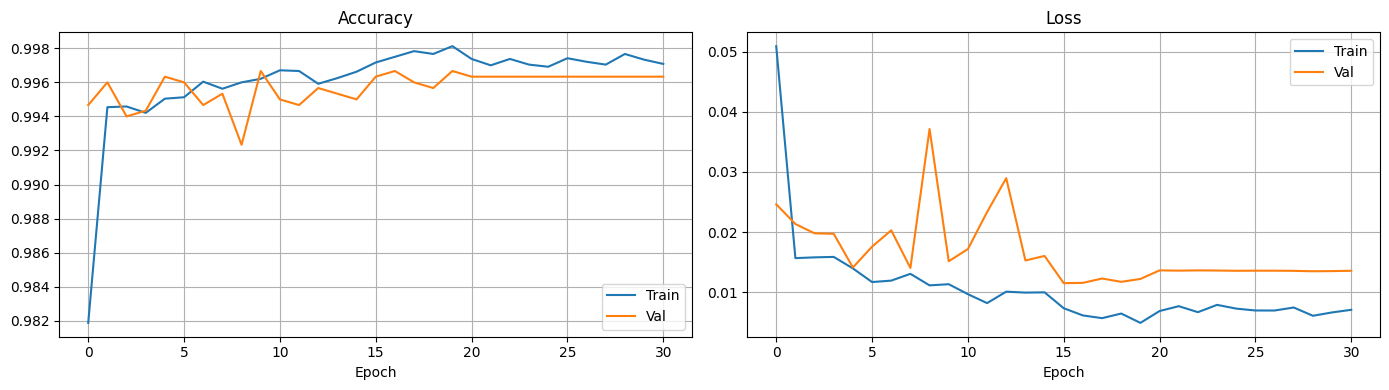

In [15]:
def plot_history(*histories):
    combined = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for h in histories:
        for k in combined:
            combined[k].extend(h[k])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(combined['train_acc'], label='Train')
    ax1.plot(combined['val_acc'],   label='Val')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)

    ax2.plot(combined['train_loss'], label='Train')
    ax2.plot(combined['val_loss'],   label='Val')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_p1, history_p2)

Test Loss: 0.0088   Test Accuracy: 0.9970


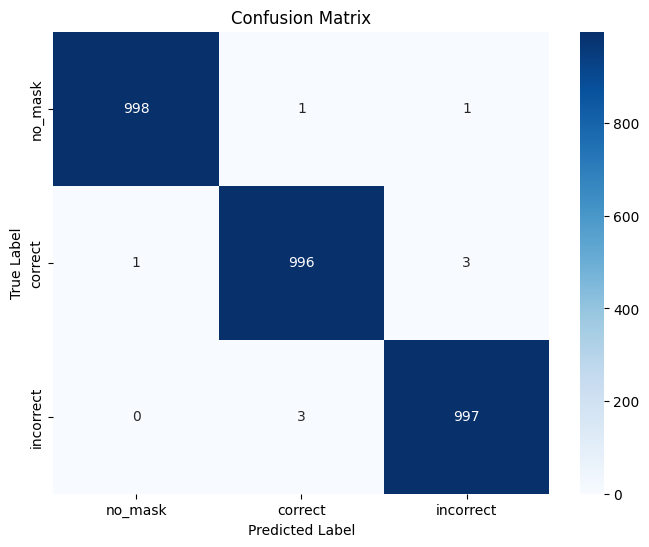

              precision    recall  f1-score   support

     no_mask       1.00      1.00      1.00      1000
     correct       1.00      1.00      1.00      1000
   incorrect       1.00      1.00      1.00      1000

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [16]:
test_loss, test_acc = validate_epoch(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

In [17]:
torch.save(model.state_dict(), 'mask_detection_ternary.pth')
torch.save(model,              'mask_detection_ternary_full.pth')
print("Saved mask_detection_ternary.pth and mask_detection_ternary_full.pth")

try:
    dummy = torch.randn(1, 3, 224, 224).to(device)
    torch.onnx.export(
        model, dummy, 'mask_detection_ternary.onnx',
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    )
    print("Saved mask_detection_ternary.onnx")
except Exception as e:
    print(f"ONNX export failed: {e}")


Saved mask_detection_ternary.pth and mask_detection_ternary_full.pth
ONNX export failed: No module named 'onnxscript'


In [18]:
try:
    from google.colab import files
    files.download('mask_detection_ternary.pth')
    files.download('mask_detection_ternary_full.pth')
    if os.path.exists('mask_detection_ternary.onnx'):
        files.download('mask_detection_ternary.onnx')
except Exception:
    print("Download manually:")
    print("  files.download('mask_detection_ternary.pth')")
    print("  files.download('mask_detection_ternary_full.pth')")
    print("  files.download('mask_detection_ternary.onnx')")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
!pip install onnx onnxscript -q

try:
    export_model = model._orig_mod
except AttributeError:
    export_model = model

export_model.eval().to(device)

dummy = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    export_model,
    dummy,
    'mask_detection_ternary.onnx',
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
)
print("Saved mask_detection_ternary.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.7 MB/s eta 0:00:00


W0620 02:57:30.166000 5164 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV3SmallClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3SmallClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: adapt: Assertion `node-

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved mask_detection_ternary.onnx
